# Face recognition

Uno dei pilastri della visione artificiale è la Face recognition. Essa si basa su una pipeline rigida da seguire. 

## Viola-Jones
L'algoritmo di *Viola-Jones* permette di individuare le Haar-like feature e successivamente Adaboost permette di selezionarle. 
L'algoritmo calcola le feature tramite un *kernel* composto da aree scure e bianche, scorrendo sull'immagine, e sottraendo la somma delle intensità dei pixel delle zone chiare e scure. 

## Immagine Integrale

Per eludere la difficoltà computazionale dovuta al calcolo delle somme di tutte le intensità dei pixel, Viola e Jones hanno introdotto il concetto di *immagine integrale*: essa permette di ridurre il costo computazionale e calcolare in maniera più semplice le somme delle intesnità dei pixel.

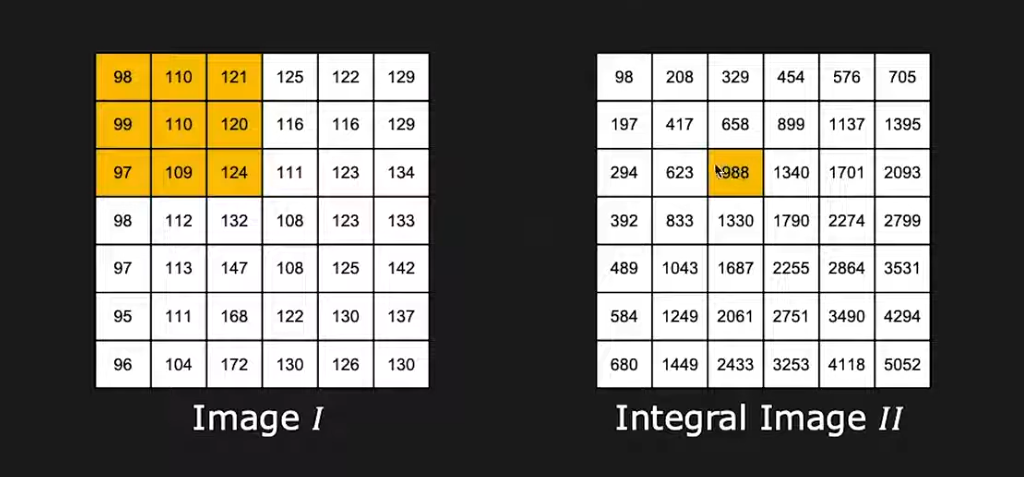

Si può osservare il funzionamento: la cella s(i,j) rappresenterà la somma dei pixel del rettangolo che va dall'origine dell'immagine(0,0) fino alla cella (i,j) delle celle superiori in alto a sinistra, in questo modo sarà molto più veloce O(1) calcolare e valutare le **Haar-like features**.

## Adaboost
Una volta costruito il *feature vector*, si pone il problema di gestire l'elevata dimensionalità per classificare l'immagine come volto o non-volto. Non tutte le feature, infatti, sono ugualmente informative, e risulta quindi desiderabile concentrarsi su quelle più significative. 
Adaboost svolge un doppio ruolo:

- seleziona automaticamente le feature rilevanti
- combina i classificatori deboli associati a tali feature per ottenere un classificatore finale più accurato

Il *boosting* consiste nel costruire un classificatore $h(x)$ come combinazione di $m$ classificatori semplici, detti *weak learners*. Il classificatore $h(x)$ prende in input un vettore di feature $x$ e restituisce un **valore binario**, tipicamente +1 o -1, corrispondente rispettivamente alle classi *volto* e *non-volto*.

Nel caso di AdaBoost, il classificatore finale è definito come una combinazione pesata dei classificatori deboli. 
I classificatori deboli vengono determinati in modo iterativo. A ogni iterazione, il weak learner si concentra sui campioni più difficili da classificare.

## Cascade classifiers (Viola-Jones)
Al termine della procedure di addestramento, si ottiene una sequenza di $m$ classificatori deboli. Il classificatore forte è definito come:

$$h(\mathbf{x}) = \text{sign}\left(\sum_{t=1}^m \alpha_t h_t(\mathbf{x})\right)$$

Successivamente, i classificatori vengono organizzati in una struttura a cascata (Fig. 2.6), applicata a ciascuna sotto-finestra dell'immagine. Un risultato positivo a uno stadio attiva la valutazione dello stadio successivo, mentre un risultato negativo comporta l'immediato scarto della sotto-finestra.
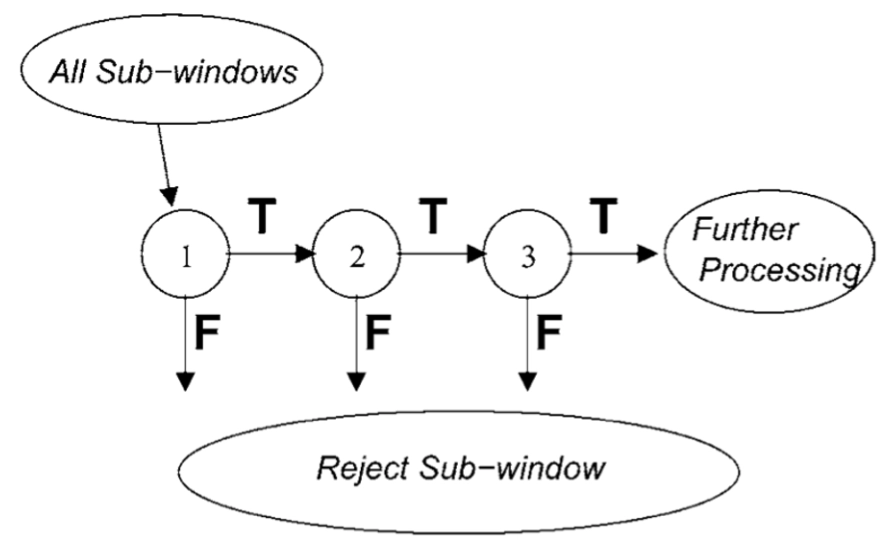

Questa struttura è motivata dal fatto che, in una tipica immagine, la grande maggioranza delle sotto-finestre non contiene volti. Di conseguenza, i primi stadi della cascata sono progettati per eliminare rapidamente un elevato numero di esempi negativi con un costo computazionale ridotto, mentre gli stadi successivi, più complessi, si concentrano su un numero progressivamente minore di candidati.

Tutta la complessa architettura di rilevamento di Viola-Jones è stata implementata e resa celebre dalla libreria OpenCV. Nella pratica, la fase di *addestramento* (estremamente lunga) viene eseguita a monte, salvando i classificatori a cascata forti all'interno di file `.xml` (chiamati Haar Cascades).

In fase di *inferenza*, è sufficiente caricare questi file e applicare il metodo `detectMultiScale` sull'immagine convertita in scala di grigi. Ecco un esempio di applicazione in real-time su un flusso video per rilevare volti e occhi:

In [ ]:
import cv2
import os

faces_xml = os.path.join(cv2.data.haarcascades,'haarcascade_frontalface_alt.xml')
eyes_xml = os.path.join(cv2.data.haarcascades,'haarcascade_eye_tree_eyeglasses.xml')

face_cascade = cv2.CascadeClassifier()
eyes_cascade = cv2.CascadeClassifier()

# -- 1. Load the cascades

if not face_cascade.load(faces_xml):
    print('-- (!)Error loading face cascade')
    exit(0)

if not eyes_cascade.load(eyes_xml):
    print('-- (!)Error loading eyes cascade')
    exit(0)

# -- 2. Read the video stream
camera = cv2.VideoCapture(0)
if not camera.isOpened():
    print('--(!) Error opening video caputre') 
    exit(0)

while True:
    ret, frame = camera.read()
    if frame is None:
        print('-- (!)Error opening video capture')
        break

    # La rilevazione di Viola-Jones lavora sulle inensita' dei pixel
    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    # frame_gray = cv2.equalizeHist(frame_gray) # Opzionale per migliorare il contrasto

    # -- Detect faces (applica la cascata all'intera immagine)

    """
    -detectMultiScale è la funzione (l'azione).
    -faces è l'output (il risultato), ovvero
    una matrice NumPy dove ogni riga rappresenta un volto confermato.
    """
    faces = face_cascade.detectMultiScale(frame_gray)
    for(x,y,w,h) in faces:
        center = (x+w //2, y+h // 2 )

        # Estrae la Region of Interest (ROI) del volto 
        # Slicing delle matrici
        faceROI = frame_gray[y:y + h, x:x+w]

        # -- In each face, detect eyes (applica la cascata solo all'interno del volto)
        eyes = eyes_cascade.detectMultiScale(faceROI)
        for(x2,y2,w2,h2) in eyes:
            eye_center = (x+x2+w2 //2, y+y2+h2 // 2 )
            radius = int(round((w2+h2) * 0.25))
            frame = cv2.circle(frame, eye_center, radius, (255,0,0), 4)

        # Disegna un rettangolo attorno al volto
        frame = cv2.rectangle(frame, (x,y), (x+w, y+h), (255,0,255), 4)

    cv2.imshow('Capture - Face detection', frame)
    if cv2.waitKey(10) == 27: # Esce se si preme il tasto ESC
        break

: 